

<p align="center">
    <img src="https://github.com/GeostatsGuy/GeostatsPy/blob/master/TCG_color_logo.png?raw=true" width="220" height="240" />

</p>

## PGE 383 Graduate Student Project


## A Comparative Analysis: Partial Dependence Plots vs. SHAP Dependence Plots

#### Suin Choi
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering 

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Elnara Rustamzade, Graduate Student, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/in/elnara-rustamzade/)


### Executive Summary

The main objective of this project is to investigate the reliability of Partial Dependence Plots (PDPs) versus SHAP dependence plots under common conditions of feature correlation and interaction. While PDPs are widely used, their core assumption of feature independence can be problematic. To investigate this, we created three synthetic "ground truth" datasets (independent, correlated, and interacting) to evaluate how each method visualizes a model's behavior under these specific conditions. Our results indicate that 1D PDPs provide a nearly identical "averaged" visualization for all three distinct scenarios, masking critical underlying relationships. In contrast, SHAP plots successfully visualized these differences, representing correlations as diagonal bands and interactions as vertical dispersion. Further experiments confirmed these findings generalize to classification and that XAI tools explain the model's learned behavior, not the data's raw truth. We recommend using SHAP dependence plots as a primary tool for exploratory model analysis, as they offer a more robust interpretation for complex models where feature dependencies are common.

### Key Concepts: Explainable Artificial Intelligence (XAI) Methodologies
Modern "black-box" models lack transparency. To trust them, we must use **Explainable Artificial Intelligence (XAI)**. This project compares two fundamental XAI approaches.

1. **Partial Dependence Plots (PDP)**: The Global Perspective
- What it is: PDPs show the **average expected relationship** between a feature and the model's prediction.

- Calculation: They marginalize over the distribution of all other features, averaging their effects.

- Key Limitation: This averaging **assumes the feature of interest is independent** of all other features. When features are correlated (e.g., age and income), this assumption breaks, leading to misleading interpretations.

2. **Shapley Values (SHAP)**: The Local Perspective
- What it is: Derived from game theory, SHAP attributes a precise contribution value to each feature for every single prediction.

- Calculation: It calculates the weighted average of a feature's marginal contribution **across all possible feature combinations**.

- Key Advantage: SHAP values are mathematically fair (satisfying additivity, symmetry, etc.) and **inherently account for feature interactions and correlations**, making them a more robust standard for explaining complex models.



### Project Objective

The main objective of this project is to conduct a **comprehensive comparison between PDPs and SHAP dependence plots**. To achieve this, we test their performance across a spectrum of controlled scenarios, including **varying data structures (correlated vs. interacting), different model capabilities (Linear vs. Random Forest), and distinct problem types (regression vs. classification)**. This multi-faceted investigation aims to provide a holistic recommendation on the practical utility of each tool, highlighting critical interpretation pitfalls and their respective strengths in model discovery.

In [2]:
import numpy as np                                                                      # For numerical operations (arrays)
import pandas as pd                                                                     # For data manipulation (DataFrames)
import matplotlib.pyplot as plt                                                         # For plotting (charts, figures)
import seaborn as sns                                                                   # For statistical plotting (heatmaps)
import shap                                                                             # For SHAP value calculation and plots
from sklearn.base import is_classifier                                                  # For judgement of model types
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier              # Models to explain
from sklearn.linear_model import LinearRegression                                       
from sklearn.inspection import PartialDependenceDisplay                                 # For PDP plots

### Functions

The following functions will be used in the workflow. The purpose of each function is also provided.

In [3]:
# Visualize data distribution
def visualize_data(df, title):
    fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))
    fig.suptitle(title, fontsize=12, y=1.0)
    
    # 1. Histogram: X1
    sns.histplot(df['X1'], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution of X1')
    axes[0].set_xlabel('X1 Value')

    # 2. Histogram: X2
    sns.histplot(df['X2'], kde=True, ax=axes[1], color='salmon')
    axes[1].set_title('Distribution of X2')
    axes[1].set_xlabel('X2 Value')

    # 3. Histogram: Target Y
    sns.histplot(df['Y'], kde=True, ax=axes[2], color='green')
    axes[2].set_title('Distribution of Target Y')
    axes[2].set_xlabel('Y Value')

    # 4. Scatter Plot: X1 vs X2
    sns.scatterplot(x='X1', y='X2', data=df, ax=axes[3], alpha=0.5, color='purple')
    axes[3].set_title('Scatter: X1 vs X2')
    axes[3].set_xlabel('X1')
    axes[3].set_ylabel('X2')

    # 5. 상관관계 히트맵
    corr = df.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[4], vmin=-1, vmax=1)
    axes[4].set_title('Correlation Matrix')

    plt.tight_layout()
    plt.show()

# Train model, calculate SHAP and visualize PDP & SHAP
def train_and_visualize(model, X, y, title, feature='X1', interaction_idx='auto'):
 
    # 1. Train Model
    model.fit(X, y)
    
    # 2. Calculate SHAP values
    if isinstance(model, LinearRegression):
        explainer = shap.LinearExplainer(model, X)
    else:
        explainer = shap.TreeExplainer(model)
        
    shap_values = explainer.shap_values(X)

    if is_classifier(model):
            shap_values_target = shap_values[1] if isinstance(shap_values, list) else shap_values[:,:,1]
            pdp_response = 'predict_proba' 
    else:
        shap_values_target = shap_values
        pdp_response = 'auto'

    # 3. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f'{title}', fontsize=13, y=1.00)

    # --- Plot A: PDP ---
    ax1.set_title(f'PDP for {feature}')
    PartialDependenceDisplay.from_estimator(
        model, X, features=[feature], ax=ax1, 
        response_method=pdp_response,
        line_kw={"color": "tab:blue", "linewidth": 2}
    )
    ax1.set_ylabel("Partial dependence", fontsize=12)
    
    # --- Plot B: SHAP Dependence ---
    ax2.set_title(f'SHAP Dependence for {feature}')
    shap.dependence_plot(
        feature, 
        shap_values_target, 
        X, 
        ax=ax2, 
        show=False, 
        interaction_index=interaction_idx
    )
    ax2.set_ylabel("SHAP Value", fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Visualize PDP in 2D
def plot_interaction_comparisons(model, X, y, title, feature_pair=('X1', 'X2')):

    # 1. Train Model 
    model.fit(X, y)

    # 2. Calculate SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # 3. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title, fontsize=13, y=1.00)

    # --- Plot A: 2D PDP ---
    ax1.set_title(f'2D PDP ( {feature_pair[0]} & {feature_pair[1]})')
    
    PartialDependenceDisplay.from_estimator(
        model, 
        X, 
        features=[feature_pair], 
        ax=ax1,
        contour_kw={'cmap': 'viridis'} 
    )

    # --- Plot B: 1D SHAP ---
    ax2.set_title(f'SHAP Dependence for {feature_pair[0]}')
    
    shap.dependence_plot(
        feature_pair[0], 
        shap_values, 
        X, 
        ax=ax2, 
        show=False, 
        interaction_index=feature_pair[1]
    )
    ax2.set_ylabel("SHAP Value", fontsize=12)

    plt.tight_layout()
    plt.show()


### Load Data

This workflow does not load external data. Instead, three distinct synthetic datasets (N=1000) are generated in memory to create a controlled dataset for testing interpretability methods.

**Feature Dictionary**
| The base dataset consists of two primary predictive features (X1, X2), two noise features (X3, X4), and a continuous target variable (Y).
As the data is synthetic, the features are unitless.
- X1 (Continuous): A primary predictive feature.
- X2 (Continuous): A second predictive feature. Its relationship with X1 is modified in each scenario.
- X3 (Continuous): A noise feature, independent and unrelated to the target Y.
- X4 (Continuous): A noise feature, independent and unrelated to the target Y.
- Y (Continuous): The target variable to be predicted. Its value is a function of the features.

In [4]:
# Set random seed for reproducibility
np.random.seed(42)
N_SAMPLES = 1000

# Create base random data
X_data = np.random.rand(N_SAMPLES, 4)
X1_base, X2_base, X3_base, X4_base = X_data.T
base_noise = np.random.randn(N_SAMPLES) * 0.1

### Workflow overview of 'A comparative analysis: partial dependence plots vs. SHAP dependence plots'

A summary of the workflow is provided below: 

1. Data Preparation and Scenario Design

    Generate three synthetic datasets (Independent, Correlated, Interacting) to isolate data dependency from model complexity.
2. Experiment 1: Impact of Feature Dependence

    Compare 1D PDP against 1D SHAP across all scenarios to test how PDP's global averaging conceals the effects of correlation and interaction.
3. Experiment 2: 2D PDP vs 1D SHAP Comparison
    
    Compare 2D PDP (requiring manual verification) with 1D SHAP (providing automatic discovery via dispersion) to establish SHAP's superior efficiency in revealing interactions.
4. Experiment 3: Impact of Model Choice on XAI Results
    
    Train a simple LinearRegression model on interacting data to demonstrate that XAI explains the model's logic (diagnostic power), not the data's absolute truth."
5. Experiment 4: Extending to Classification

    Extend the analysis to a binary classification problem to confirm that the findings on PDP's smoothing and SHAP's detail generalize across problem domains.
6. Experiment 5: Stability & Robustness of Explanations

    Quantify the explanation variance by retraining models multiple times to determine which method offers a more stable and reliable interpretation when faced with inherent model variance.



### Data preparation and Scenario Design

This initial step involves the generation of three synthetic datasets and a subsequent analysis. We generate histograms, scatter plots, and a correlation matrix to provide a qualitative and quantitative overview of the features, ensuring they match our intended experimental design.

**Experimental Scenarios**
| From the above base data, I generate three distinct scenarios by manipulating the relationship between the features and the target. 
* Scenario 1 (Independent): X1 and X2 are independent. The target Y is a simple additive function of these features: Y = f(X1) + f(X2) + noise
* Scenario 2 (Correlated): The Y function is identical to Scenario 1, but the X2 is synthetically made to be strongly correlated with X1. This tests the tool's ability to handle data-level dependencies.
* Scenario 3 (Interacting): X1 and X2 are independent but their impact on Y is non-additive. An interaction term (X1 $\cdot$ X2) is added to the calculation for Y. This tests the tool's ability to handle model-level complexity.

Correlation describes how input features linearly associate with one another, whereas interaction describes a non-additive relationship where the impact of one feature on the target depends on the value of another. 

We designed our scenarios to decouple these effects, allowing us to assess how PDP and SHAP respond to data dependencies versus model complexity.

In [5]:
# Scenario 1: Independent Features
# Y depends linearly on X1 and X2. X3, X4 are noise.
y_ind = (2 * X1_base) + (5 * X2_base) + base_noise
df_ind = pd.DataFrame({
    'X1': X1_base, 'X2': X2_base, 'X3': X3_base, 'X4': X4_base, 'Y': y_ind
})
X_ind = df_ind[['X1', 'X2', 'X3', 'X4']]


# Scenario 2: Correlated Features
# X2 is now strongly correlated with X1. Y formula is the same.
X1_corr = X1_base
# Introduce correlation
X2_corr = 0.8 * X1_corr + np.random.rand(N_SAMPLES) * 0.2
y_corr = (2 * X1_corr) + (5 * X2_corr) + base_noise
df_corr = pd.DataFrame({
    'X1': X1_corr, 'X2': X2_corr, 'X3': X3_base, 'X4': X4_base, 'Y': y_corr
})
X_corr = df_corr[['X1', 'X2', 'X3', 'X4']]


# Scenario 3: Interacting Features
# X1 and X2 are independent, but their interaction affects Y.
y_int = (2 * X1_base) + (5 * X2_base) + (10 * X1_base * X2_base) + base_noise
df_int = pd.DataFrame({
    'X1': X1_base, 'X2': X2_base, 'X3': X3_base, 'X4': X4_base, 'Y': y_int
})
X_int = df_int[['X1', 'X2', 'X3', 'X4']]

- **Histograms**: These plots are used to examine the probability distribution of a single feature. They help identify its fundamental shape, skewness, modality, or potential outliers.

- **Scatter Plots**: These plots visualize the bivariate relationship between two continuous features. They are essential for detecting linear trends, non-linear patterns, clusters, or outliers.

- **Correlation Matrix**: This matrix provides a quantitative summary of the linear relationship between all pairs of features. Values range from -1 (strong negative correlation) to +1 (strong positive correlation), with values near 0 indicating no linear relationship.

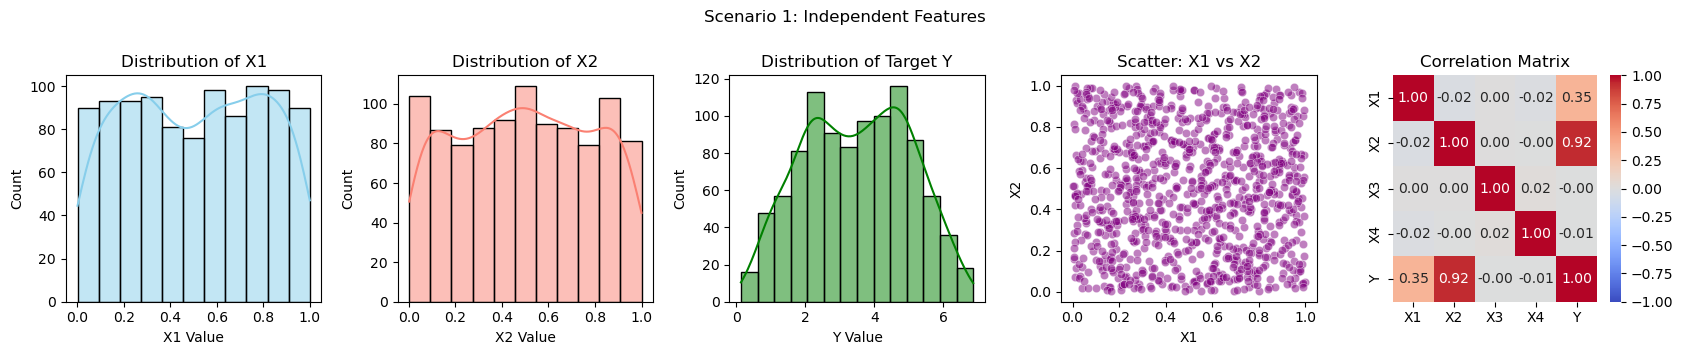

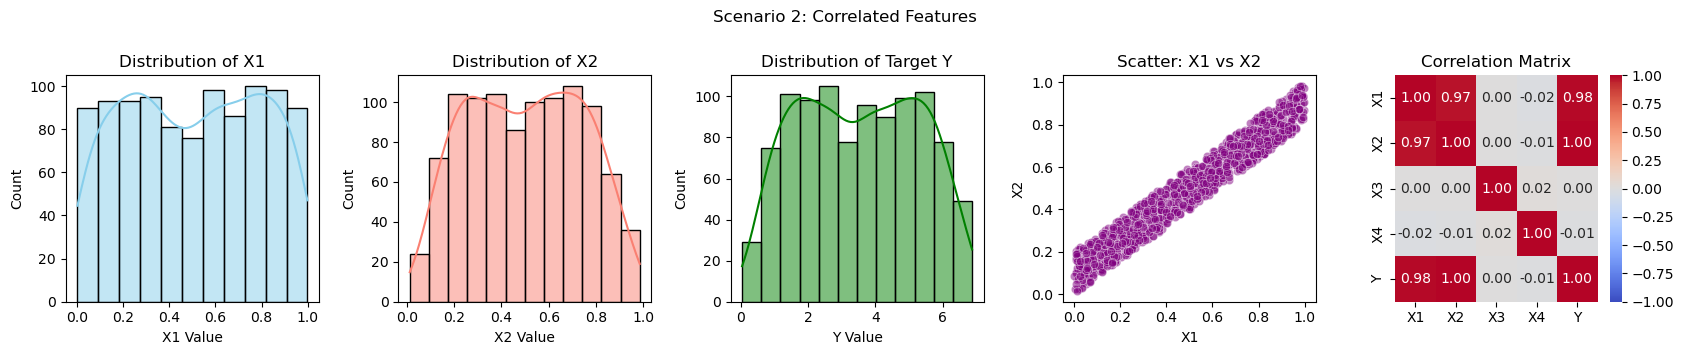

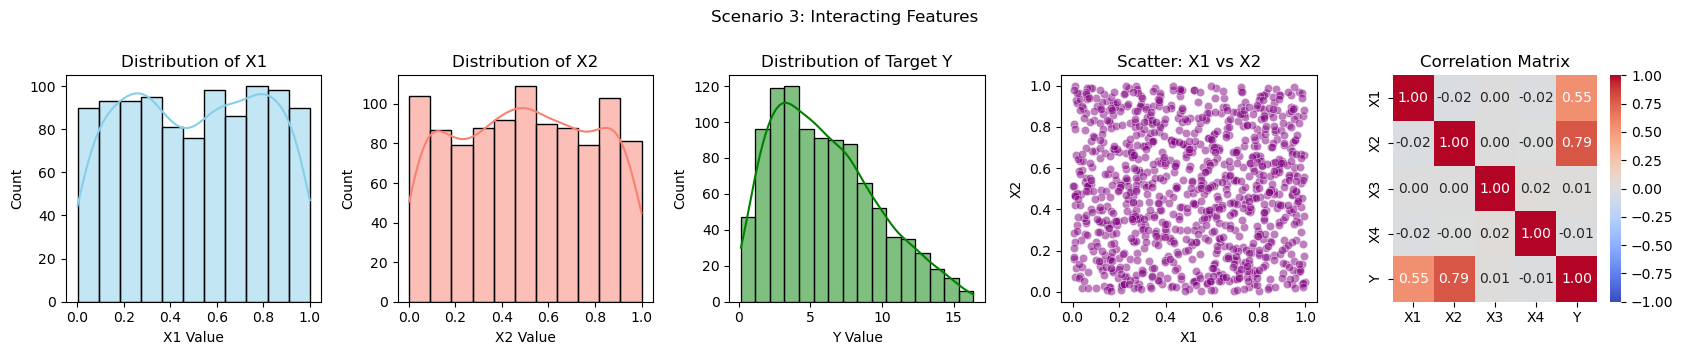

In [6]:
scenarios_data = [
    ("Scenario 1: Independent Features", df_ind),
    ("Scenario 2: Correlated Features", df_corr),
    ("Scenario 3: Interacting Features", df_int)
]

for title, df in scenarios_data:
    visualize_data(df, title)

### Comments 

- From the Scatter Plot, we get our primary visual confirmation. We observe a random cloud for the Independent (Scenario 1) and Interacting (Scenario 3) datasets, confirming their independence. In contrast, we see a clear diagonal trend for the Correlated (Scenario 2) dataset.

- From the Correlation Matrix, we quantify these findings. We verify that the X1-X2 correlation is near 0 for Scenarios 1 & 3 but high (e.g., 0.97) for Scenario 2. We also confirm that our noise features (X3, X4) show no correlation with the target Y.


### Experiment 1: Impact of Feature Dependence 

This foundational experiment investigates the core assumption of 1D Partial Dependence Plots (PDPs): feature independence. The objective is to test how both PDP and SHAP visualize model behavior when this assumption is systematically violated by feature correlation and feature interaction.

To achieve this, I trained a RandomForestRegressor on our three synthetic dataset scenarios. I then directly compared the 1D PDP against the 1D SHAP dependence plot for feature X1. This controlled comparison allows to visually determine if PDP's averaging masks these critical complexities, and how effectively SHAP reveals them.



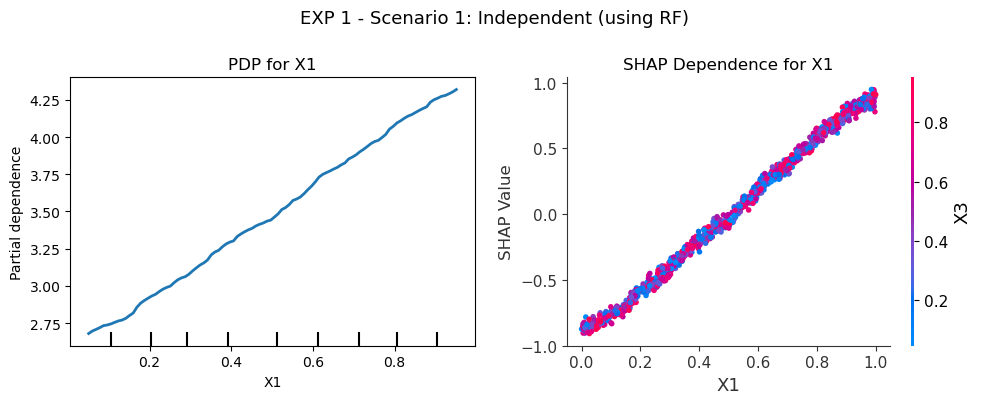

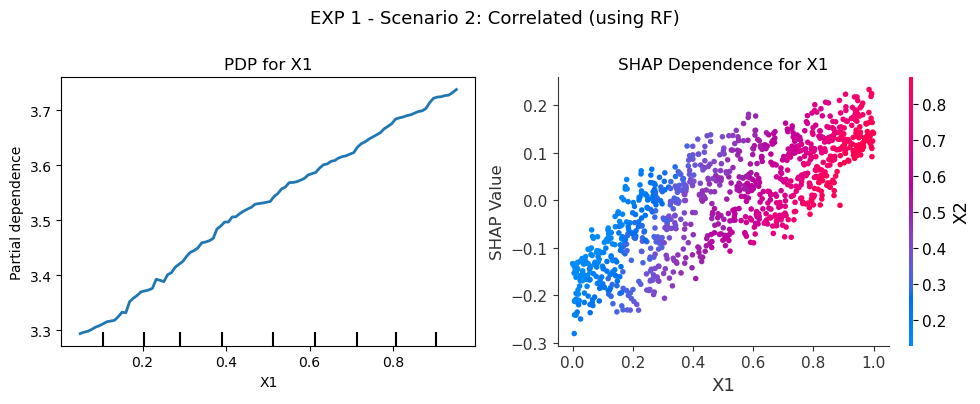

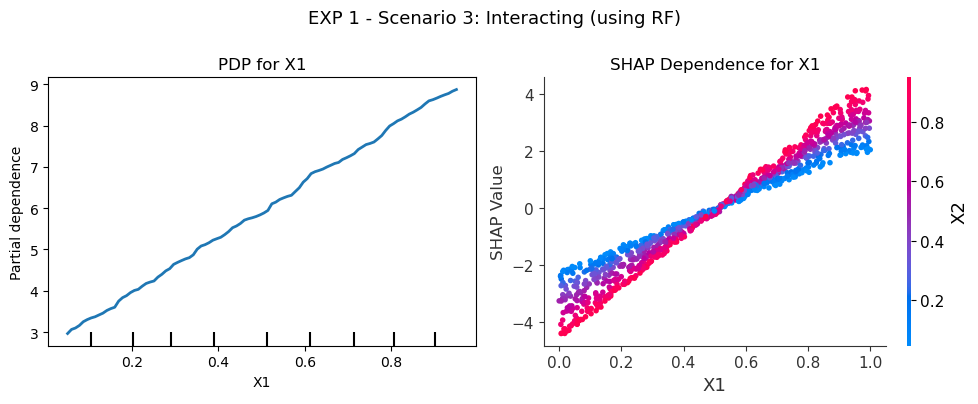

In [7]:
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# List of scenarios (Name, X_data, y_data)
scenarios = [
    ("Scenario 1: Independent", X_ind, y_ind),
    ("Scenario 2: Correlated", X_corr, y_corr),
    ("Scenario 3: Interacting", X_int, y_int)
]

for name, X_curr, y_curr in scenarios:
    train_and_visualize(
        model=rf_base,         
        X=X_curr, 
        y=y_curr, 
        title=f"EXP 1 - {name} (using RF)",
        interaction_idx='auto' 
    )

### Comment

Based on the figures above, we can interpret as follows.

**Scenario 1: Independent Features**
* When features are uncorrelated, the average effect (PDP) and the individual effect (SHAP) are the same. 

**Scenario 2: Correlated Features**
* PDP remains a smooth line, looking similar to Scenario 1.The PDP fails to capture the data structure, calculating averages.
* On the other hand, SHAP plot reveals a distinct pattern. The colors (representing X2) changes from blue to red as X1 increases, acknowledging that one feature's impact is highly coupled with its correlated feature.

**Scenario 3: Interacting Features**
* PDP still shows a single, steep monotonic line. While this suggests a strong positive relationship on average, it fails to capture the variance in the feature's effect. 
* In contrast, SHAP plot exhibits vertical dispersion. As X1 value deviates from its mean (approx. 0.)5, the impact on the prediction varies depending on X2 values (indicated by separation of red and blue points)
* This highlights that PDP averages out complex dependencies, while SHAP exposes the underlying mechanism.

### Experiment 2: 2D PDP vs 1D SHAP Comparison

Following the experiment 1, which demonstrated that 1D PDPs flatten complex relationshis, a critical question arises: Is it impossible for PDP to detect interactions?

This experiment aims to clarify the capabilities and limitations of PDP. While 1D PDPs show marginalized averages, interactions can be visualized by extending PDP to two dimensions (a 2-way PDP or heatmap) which shows the joint effect of two features.

Therefore, we will directly compare 2D PDP (heatmap) against the 1D SHAP (dependence plot).

To conduct this test, we train the RandomForestRegressor on all three scenarios and plot the 2D PDP for (X1, X2) pair for each, comparing them against their 1D SHAP plots.


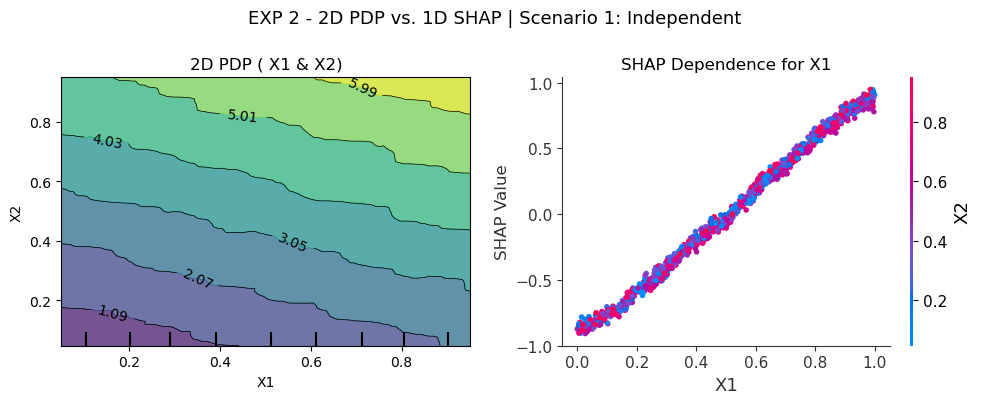

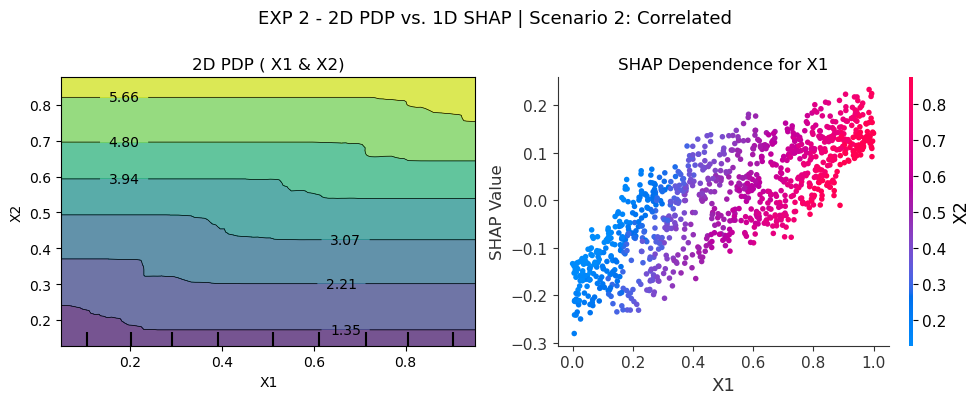

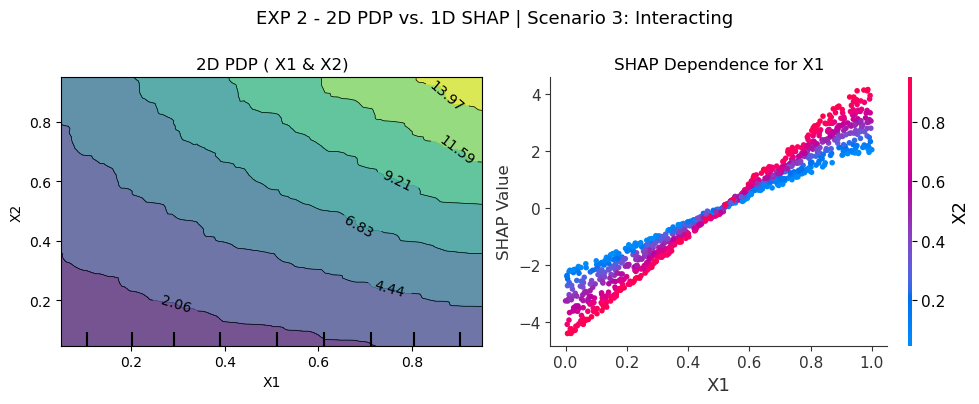

In [8]:
for name, X_curr, y_curr in scenarios:
    plot_interaction_comparisons(
        model=rf_base,         
        X=X_curr, 
        y=y_curr, 
        title=f"EXP 2 - 2D PDP vs. 1D SHAP | {name}",
        feature_pair=('X1', 'X2') 
    )

### Comment 

This experiment confirms that while PDP can visualize interactions, it does so with a significant limitation compared to SHAP's automatic discovery. 

- In Scenario 3, the 2D PDP  successfully reveals the interaction showing that the predicted value rises sharply when both X1 and X2 are high. This confirms the interaction between X1 and X2 mechanism was captured.
- However, **a 2D PDP requires the analyst to know in advance which pair of features to check. This is impractical for high-dimensional data (e.g., 100 features would require checking 4,950 pairs), making it a tool for verification of a known hypothesis.**
- A 1D **SHAP plot**, as also seen in Experiment 1, **automatically reveals the interaction through vertical dispersion.**

### Experiment 3: Impact of Model Choice on XAI Results

This experiment addresses a fundamental question: Do XAI tools explain the data, or do they explain the model? 

To investigate this, we deliberately train a simple LinearRegression model on our most complex dataset, Scenario 3 (Interacting Features).

It allows us to verify whether PDP and SHAP will report the true interaction hidden in the data or if they will merely (and faithfully) reflect the model's own simplified understanding.

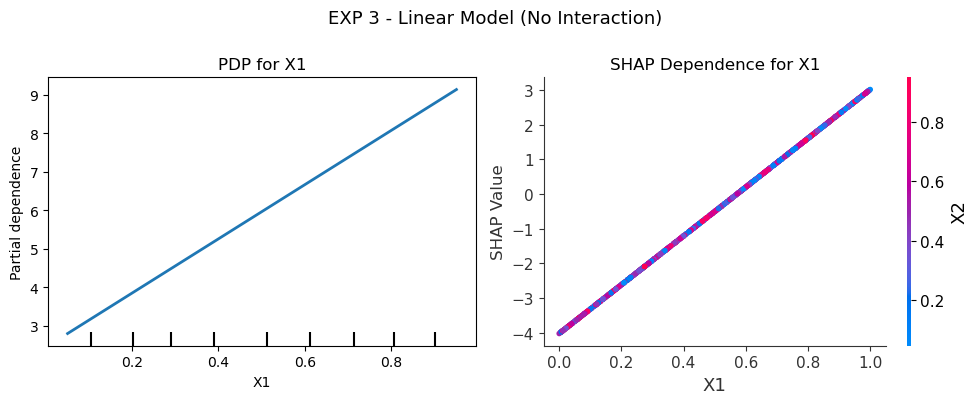

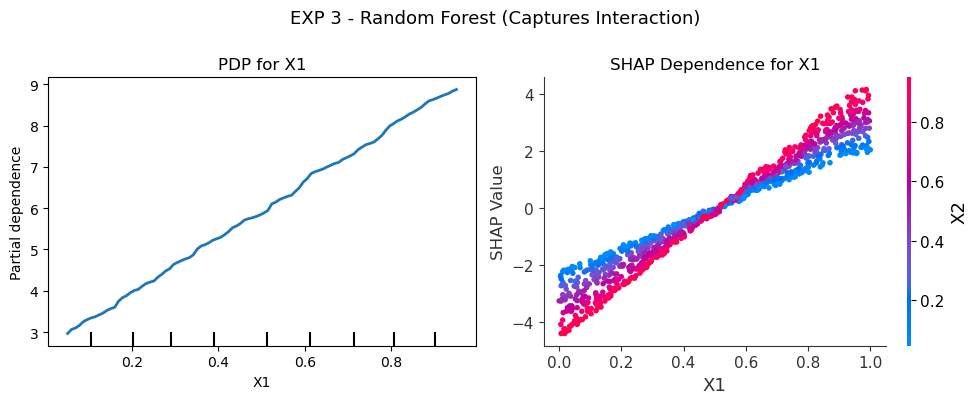

In [9]:
models_to_compare = [
    ("Linear Model (No Interaction)", LinearRegression()),
    ("Random Forest (Captures Interaction)", RandomForestRegressor(n_estimators=100, random_state=42))
]

for model_name, model_inst in models_to_compare:
    idx_setting = "X2" if "Linear" in model_name else "auto"
    
    train_and_visualize(
        model=model_inst, 
        X=X_int, 
        y=y_int, 
        title=f"EXP 3 - {model_name}",
        interaction_idx=idx_setting
    )

### Comment

- Despite the data containing strong feature interactions, both the PDP and SHAP plots display simple, straight linear trends.
The characteristic vertical dispersion depending on X2 observed in the Random Forest SHAP plot has complete vanished in the Linear Regression SHAP.

- Since the linear model failed to learn the interaction, the interpretability tools faithfully reported a linear relationship. 

- This gives a lesson that **'Interpretability tools explains the model's learned logic, not the causation'**.

### Experiment 4: Extending to Classification

This experiment tests the universality of our findings by extending the analysis from regression to classification. The objective is to verify if PDP's smoothing effect and SHAP's ability to expose nuanced detail persist in this new context.

First, I convert the interacting dataset (from Scenario 3) into a binary classification problem.


In [10]:
# We use the existing 'X_int' dataset (Scenario 3)
X1_vals = X_int['X1']
X2_vals = X_int['X2']

# Create logits with strong interaction
logit = (2 * X1_vals) + (5 * X2_vals) + (10 * X1_vals * X2_vals)

# Center logits to ensure a somewhat balanced dataset
logit_centered = logit - np.mean(logit)

# Apply Sigmoid function to convert logits to probabilities
prob = 1 / (1 + np.exp(-logit_centered))

# Create binary target based on threshold 0.5
y_class = (prob > 0.5).astype(int)

print(f"Class Balance (0 vs 1): {np.bincount(y_class)}")

Class Balance (0 vs 1): [555 445]


Then, we train a RandomForestClassifier model based on this binary dataset.

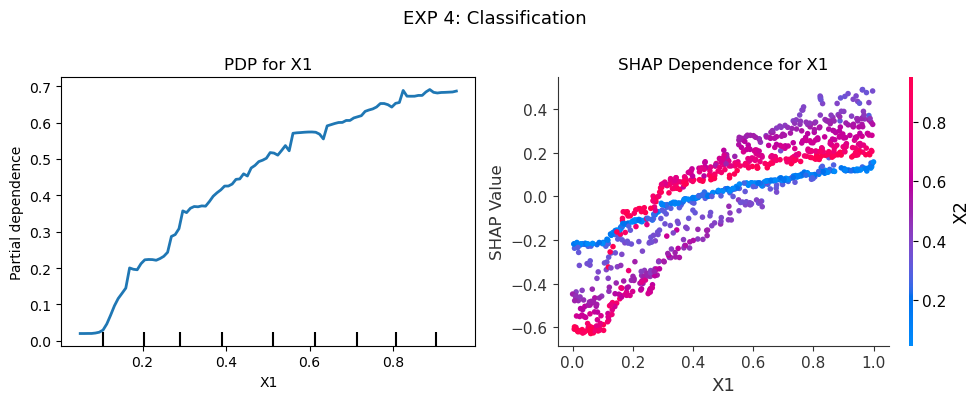

In [11]:
model_rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

train_and_visualize(
    model=model_rfc,
    X=X_int,
    y=y_class,
    title="EXP 4: Classification",
    feature='X1'
)

### Comment

- This experiment confirms that the PDP also simplifies the binary classification mechanism, smoothing the model's output into an **average probability curve.** 

- In stark contrast, the SHAP plot uncovers the true underlying complexity.  It clearly reveals the strong interaction between X1 and X2, evidenced by the **distinct vertical dispersion** where Red (high X2) and Blue (low X2) dots diverge at the same X1 value. 

- This demonstrates that the fundamental difference between the tools—averaging (PDP) versus individual detail (SHAP)—persists regardless of problem type.

### Experiment 5: Stability & Robustness of Explanations

Having established what PDP and SHAP show (Experiments 1-4), this final experiment investigates how reliable or stable these explanations are. A robust explanation method should provide a consistent interpretation even if the model's internal parameters change slightly.

This experiment aims to quantify the **explanation variance**—is PDP or SHAP more stable when explaining models that are trained on the same data but with different random seeds?

- I use the complex Scenario 3 (Interacting) data, as its complexity provides a good test for stability.

- I induce model variance by training a RandomForestRegressor 8 times with different random state and a shallow depth (max. depth of 3). This shallow depth intentionally increases the model's variance, as each run will learn slightly different set of rules from the bootstraped samples.

=== Stability across runs (X1) ===
PDP  mean variance : 0.003411
SHAP mean variance : 0.001525


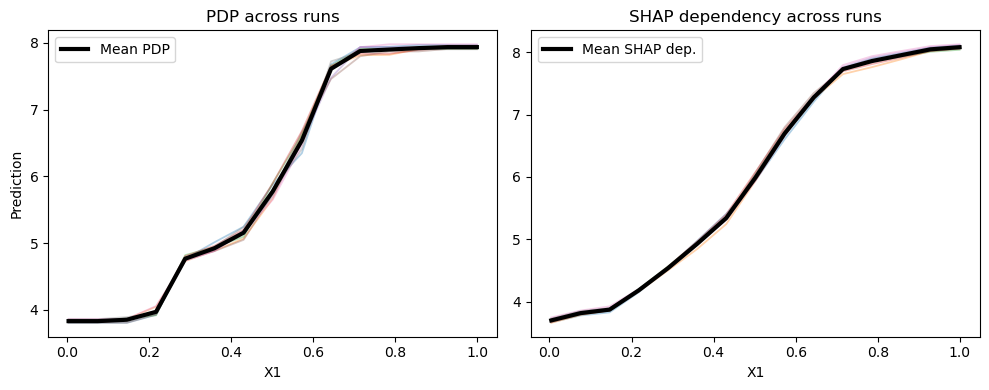

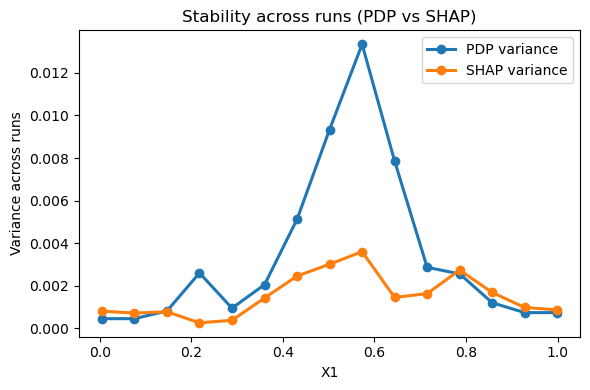

In [ ]:
X = X_int.values if isinstance(X_int, pd.DataFrame) else X_int
y = df_int['Y'].values

n_sub = min(400, X.shape[0])          # Use at most 400 samples
idx = np.random.choice(X.shape[0], n_sub, replace=False)
X_sub = X[idx]
y_sub = y[idx]

feature_index = 0                      # 0: X1
x1 = X_sub[:, feature_index]
x1_min, x1_max = x1.min(), x1.max()
grid = np.linspace(x1_min, x1_max, 15) 

n_runs = 8                             
pdp_curves = []                        
shap_curves = []                       


# Train models and store PDP/SHAP curves
for seed in range(n_runs):
    rf = RandomForestRegressor(
        n_estimators=40,
        max_depth=3,
        random_state=seed,
        n_jobs=-1
    )
    rf.fit(X_sub, y_sub)

    # Approximate PDP
    X_tmp = X_sub.copy()
    pdp_vals = []
    for v in grid:
        X_tmp[:, feature_index] = v
        y_hat = rf.predict(X_tmp)
        pdp_vals.append(y_hat.mean())
    pdp_curves.append(pdp_vals)

    # Approximate SHAP dependency 
    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X_sub)    
    ev = explainer.expected_value               
    shap_x1 = shap_vals[:, feature_index]

    shap_curve = []
    width = 0.1 * (x1_max - x1_min)             
    for v in grid:
        mask = np.abs(x1 - v) < width
        if np.any(mask):
            shap_curve.append(ev + shap_x1[mask].mean())
        else:
            shap_curve.append(np.nan)
    shap_curves.append(shap_curve)


pdp_curves = np.array(pdp_curves)   
shap_curves = np.array(shap_curves)

# Compute variance across runs
pdp_var_per_grid  = np.nanvar(pdp_curves,  axis=0)
shap_var_per_grid = np.nanvar(shap_curves, axis=0)

pdp_var_mean  = np.nanmean(pdp_var_per_grid)
shap_var_mean = np.nanmean(shap_var_per_grid)

print(" --- Stability across runs ---")
print(f"PDP  mean variance : {pdp_var_mean:.6f}")
print(f"SHAP mean variance : {shap_var_mean:.6f}")

# Plot curves per run + mean curve
plt.figure(figsize=(10, 4))

# PDP curves
plt.subplot(1, 2, 1)
for c in pdp_curves:
    plt.plot(grid, c, alpha=0.35, linewidth=1.3)
plt.plot(
    grid, np.nanmean(pdp_curves, axis=0),
    'k-', linewidth=3, label='Mean PDP'
)
plt.title('PDP across runs')
plt.xlabel('X1')
plt.ylabel('Prediction')
plt.legend()

# SHAP dependency curves
plt.subplot(1, 2, 2)
for c in shap_curves:
    plt.plot(grid, c, alpha=0.35, linewidth=1.3)
plt.plot(
    grid, np.nanmean(shap_curves, axis=0),
    'k-', linewidth=3, label='Mean SHAP dep.'
)
plt.title('SHAP dependency across runs')
plt.xlabel('X1')
plt.legend()

plt.tight_layout()
plt.show()

# Plot variance per grid point
plt.figure(figsize=(6, 4))
plt.plot(
    grid, pdp_var_per_grid,
    marker='o', linewidth=2.2, label='PDP variance'
)
plt.plot(
    grid, shap_var_per_grid,
    marker='o', linewidth=2.2, label='SHAP variance'
)
plt.xlabel('X1')
plt.ylabel('Variance across runs')
plt.title('Stability across runs (PDP vs SHAP)')
plt.legend()
plt.tight_layout()
plt.show()


### Comment

- The stability metrics confirm difference in robustness. The SHAP dependence plot's average variance is less than half that of the PDP.

- 8 PDP curves shows relatively wider spread than the 8 SHAP curves. The SHAP curves are more tightly clustered around their mean, indicating that SHAP shows more consistent result from run to run.

- The line for PDP variance is higher than the SHAP variance line across almost the entire feature space. This indicates that PDP is more sensitive to model variance than the SHAP.


### Results

- 1D PDPs concealed the underlying data structure. The plot was nearly identical for independent, correlated, and interacting scenarios, offering a misleading average view.

- SHAP plots clearly distinguished all scenarios, visualizing independence (thin line), correlation (diagonal band), and interaction (vertical dispersion).

- A key test proved XAI reflects the model's logic, not the data's truth. A Linear Model (incapable of learning interactions) produced a simple linear SHAP plot, even on complex interacting data.

- These findings were confirmed to generalize to classification tasks, where PDP averaged probabilities and SHAP revealed the hidden interaction.

### Conclusion and Implications

- 1D PDPs are insufficient for complex models as their averaging masks critical correlations and interactions.

- SHAP is a robust discovery tool. Its 1D plots automatically signal higher-order effects (like interactions) via dispersion, which 2D PDPs can only find through manual verification.

- SHAP explanations are not only more detailed but also more reliable. SHAP provides a more stable explanation that reflects the model's underlying logic rather than an artifact of a single training run. 

- **This project propose that practitioners actively leverage domain knowledge as a critical validator for XAI outputs. In real-world scenarios where mathematical ground truth is absent, a discrepancy between expert intuition (e.g., expecting an interaction) and model explanations (e.g., observing a linear trend) should not be ignored. Instead, this mismatch should be utilized as a diagnostic signal to identify model underfitting and drive further refinement.**

### References

- Scikit-Learn Developers. (2024). Partial Dependence Plots. Scikit-Learn Documentation.
Retrieved from https://scikit-learn.org/stable/modules/partial_dependence.html

- Grootendorst, M. (2022). Understanding Black-Box Models: A Practical Guide.
Retrieved from https://www.maartengrootendorst.com/blog/black-boxes/

- Lundberg, S. M., & Lee, S.-I. (2023). An Introduction to Explainable AI with Shapley Values. SHAP Documentation.
Retrieved from https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

### Suin Choi, PhD Student, Petroleum & Geosystems Engineering

I am **Suin Choi**, a graduate researcher working with Professor Michael Pyrcz on **Explainable Subsurface Modeling with Physics and Machine Learning**. My current work centers on developing interpretable, physics-consistent machine-learning workflows that enhance prediction reliability and support decision-making in subsurface energy systems. Before joining UT Austin, I completed my Master’s research on “Design of an Integrated CO₂ Transport–Injection–Storage System Using Multi-Objective Optimization and Machine Learning.” This experience strengthened my foundation in reservoir simulation and optimization, while also showing how technical workflows connect directly to operational strategy, risk mitigation, and economic outcomes.

My broader interests include data analytics, machine learning, uncertainty quantification, and subsurface modeling. My goal is to build scalable, end-to-end workflows that help stakeholders:

- Improve prediction reliability through physics-informed and explainable ML

- Identify key drivers of subsurface performance

- Reduce decision risk through transparent model interpretations

I am actively seeking research internships, industry collaborations, and future full-time opportunities where I can contribute to high-impact, data-driven decision making and subsurface energy solutions.

I would be happy to connect and discuss how my work can support your organization’s technical and strategic goals.

I can be reached at suinchoi@utexas.edu.

LinkedIn: [SuinChoi](https://www.linkedin.com/in/suin-choi-25ab26237)





#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)